In [ ]:
# 👩‍🏫 👩🏿‍🏫 What You’ll learn
# How to predict customer churn using machine learning.
# Data preprocessing techniques, including handling missing values and encoding categorical features.
# Building and evaluating a machine learning model for classification tasks.
# Using scikit-learn to train and test a model.
# Interpreting model results to make actionable business decisions.


# 🛠️ What you will create
# A predictive model that identifies customers who are likely to churn, helping the bank to focus retention efforts on high-risk customers.
# A set of visualizations and insights from the model to guide business decisions.


# For today’s daily challenge, we will predict whether customers will exist the bank in the near future (churn prediction).
# Churn refers to customers who are likely to stop using the bank’s services in the near future. In this dataset, the bank could predict churn based on:

# Account balance: Customers with low balances may be more likely to leave, especially if they feel they are not utilizing the bank’s services efficiently.
# Age and tenure: Older customers with longer relationships might be more loyal, while younger or newer customers might be more likely to leave.
# Number of products: Customers holding multiple products may have more reasons to stay loyal, so fewer products could correlate with higher churn risk.
# Credit score and transaction history: A customer’s financial activity (like a history of low balances or minimal activity) could indicate disengagement, potentially predicting churn.


# Bank Customer Churn Dataset
# This Dataset Inferential Statistics contains various attributes of the customers, such as account balance, age, gender, number of products, and transaction history, which can be used to identify patterns and predict churn behavior.



# What you need to do :
# You will find here a google colaboratory notebook. First of all, make a copy of the notebook by going to File > Save a Copy in Drive. This will open a copy of the notebook. If you want to work on another platform other than Colab that support jupyter notebook .ipnyb like VSCode you are free to download the notebook and work on it from your platform.

# Then you just need to follow the instructions and answer when you a “#TODO”.



### 1. Importation des bibliothèques et chargement des données
Nous commençons par importer `pandas` pour la manipulation de données et `seaborn/matplotlib` pour la visualisation.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Chargement du fichier localement
try:
    df = pd.read_csv('Churn_Modelling.csv')
    print("Fichier local chargé avec succès !")
except Exception as e:
    print(f"Erreur : {e}. Assurez-vous que le fichier est bien nommé 'Churn_Modelling.csv' dans le dossier files.")

display(df.head())

Fichier local chargé avec succès !


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


### 2. Prétraitement des données (Preprocessing)
Nous devons supprimer les colonnes inutiles (comme l'ID client) et convertir les textes en nombres.

In [7]:
# Suppression des colonnes non pertinentes pour la prédiction
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# Encodage des variables catégorielles
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

# Définition des features (X) et de la cible (y : 'Exited')
X = df.drop('Exited', axis=1)
y = df['Exited']

# Division 80% entraînement / 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardisation des données (pour mettre tout à la même échelle)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Données préparées avec succès.")

Données préparées avec succès.


### 3. Entraînement du modèle
Nous utilisons un `RandomForestClassifier`, très efficace pour ce type de données tabulaires.

In [8]:
# Initialisation et entraînement
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Prédictions sur l'ensemble de test
y_pred = model.predict(X_test)

print("Modèle entraîné.")

Modèle entraîné.


### 4. Évaluation et Visualisation
Regardons si le modèle est précis.

              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1607
           1       0.76      0.46      0.58       393

    accuracy                           0.87      2000
   macro avg       0.82      0.71      0.75      2000
weighted avg       0.86      0.87      0.85      2000



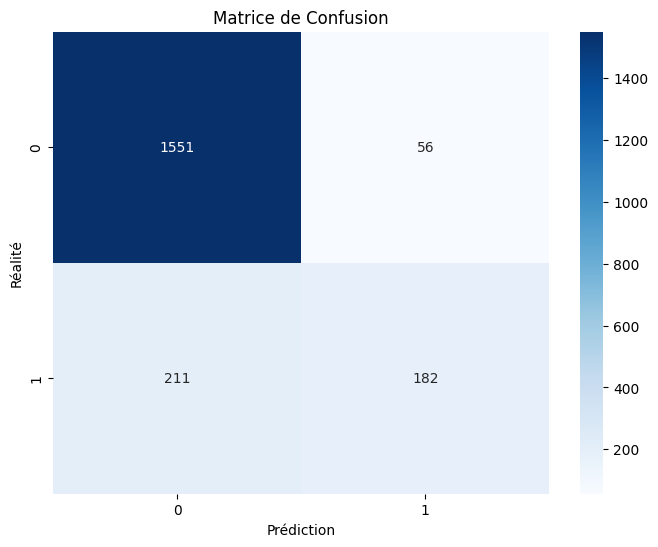

In [9]:
# Rapport de performance
print(classification_report(y_test, y_pred))

# Matrice de confusion
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Matrice de Confusion')
plt.xlabel('Prédiction')
plt.ylabel('Réalité')
plt.show()